# Finley’s tornado predictions

In 1884, John Park Finley published tornado forecasting results, showing percentage of correct forecasts exceeding 95%. It is a strongly imbalanced two-class crisp classification problem. Finley's results have been widely discussed: can we obtain them by chance?

In this example, we use *Sorbetto* to reexamine Finley's results. 
<table>
<thead>
<tr>
  <th rowspan="2">Month</th>
  <th rowspan="2">Valid period<br>(hours)</th>
  <th colspan="2">Favorable to tornadoes</th>
  <th colspan="2">Unfavorable to tornadoes</th>
</tr>
<tr>
  <th>Number of forecasts</th>
  <th>Number verified</th>
  <th>Number of forecasts</th>
  <th>Number verified</th>
</tr>
</thead>
<tbody>
<tr>
  <td>March</td>
  <td>8</td>
  <td>43</td>
  <td>6</td>
  <td>728</td>
  <td>721</td>
</tr>
<tr>
  <td>April</td>
  <td>8</td>
  <td>25</td>
  <td>11</td>
  <td>909</td>
  <td>906</td>
</tr>
<tr>
  <td>May</td>
  <td>8</td>
  <td>10</td>
  <td>8</td>
  <td>548</td>
  <td>542</td>
</tr>
<tr>
  <td>May</td>
  <td>16</td>
  <td>22</td>
  <td>3</td>
  <td>518</td>
  <td>511</td>
</tr>
</tbody>
</table>
This table should correspond to the one originaly published in [1] and was reproduced in [2].

1. Finley, J. P. (1884). Tornado predictions. American Meteorological Journal. A Monthly Review of Meteorology and Allied Branches of Study (1884-1896), 1(3), 85.
2. Murphy, A. H. (1996). The Finley affair: A signal event in the history of forecast verification. Weather and forecasting, 11(1), 3-20.

**Observations.** As the *Value Tiles* show, the values taken by ranking scores are low when the importance given to a true positive is much higher than the importance given to a true negative. Moreover, the *Entity Tiles* show that, for most of the observations, Finley's method is worse that the no-skill classifier predicting always the negative class. However, in all cases, there are importances for which Finley's method outperforms all no-skill classifiers.

In [1]:
from sorbetto.annotation import AnnotationText
from sorbetto.flavor import EntityFlavor, ValueFlavor
from sorbetto.parameterization import ParameterizationDefault
from sorbetto.performance import TwoClassClassificationPerformance
from sorbetto.ranking import Entity, RankingScore
from sorbetto.tile import EntityTile, ValueTile

In [2]:
accuracy = RankingScore.getAccuracy()
tnr = RankingScore.getTrueNegativeRate()
tpr = RankingScore.getTruePositiveRate()
npv = RankingScore.getNegativePredictiveValue()
ppv = RankingScore.getPositivePredictiveValue()

In [3]:
# construct a TwoClassClassificationPerformance object based on:
# - the number of forecasts that were favorable to tornadoes
# - the number of forecasts that were favorable to tornadoes and that have been verified
# - the number of forecasts that were unfavorable to tornadoes
# - the number of forecasts that were unfavorable to tornadoes and that have been verified
def getFinleyPerformance(
    num_favorable_forecasts,
    num_verified_favorable_forecasts,
    num_unfavorable_forecasts,
    num_verified_unfavorable_forecasts,
    name,
):
    num_tn = num_verified_unfavorable_forecasts
    num_fp = num_favorable_forecasts - num_verified_favorable_forecasts
    num_fn = num_unfavorable_forecasts - num_verified_unfavorable_forecasts
    num_tp = num_verified_favorable_forecasts
    tot = num_favorable_forecasts + num_unfavorable_forecasts
    ptn = num_tn / tot
    pfp = num_fp / tot
    pfn = num_fn / tot
    ptp = num_tp / tot
    perf = TwoClassClassificationPerformance(ptn, pfp, pfn, ptp, name=name)
    print("The accuracy for", name, "is", accuracy(perf))
    return perf

In [4]:
def drawTiles(perf_Finely):
    parameterization = ParameterizationDefault()

    flavor = ValueFlavor(perf_Finely)
    tile = ValueTile(parameterization, flavor)
    for score in [accuracy, tnr, tpr, npv, ppv]:
        label = "{} = {:.3f}".format(score.shortLabel, score(perf_Finely))
        tile.appendAnnotation(AnnotationText(score, label=label))
    tile.draw()

    prior_pos = perf_Finely._prior_pos()
    perf_no_skill_pos = TwoClassClassificationPerformance.getNoSkill(
        priorPos=prior_pos, ratePos=1.0
    )
    perf_no_skill_neg = TwoClassClassificationPerformance.getNoSkill(
        priorPos=prior_pos, ratePos=0.0
    )
    entities = [
        Entity(perf_Finely, name="Finley's method", color="b"),
        Entity(perf_no_skill_pos, name="No-skill predicting $c_+$", color="g"),
        Entity(perf_no_skill_neg, name="No-skill predicting $c_-$", color="r"),
    ]
    flavor = EntityFlavor(1, entities)
    tile = EntityTile(parameterization, flavor)
    tile.appendAnnotation(AnnotationText(accuracy))
    tile.draw()

## March (8h)

The accuracy for March (8h) is 0.9429312581063554


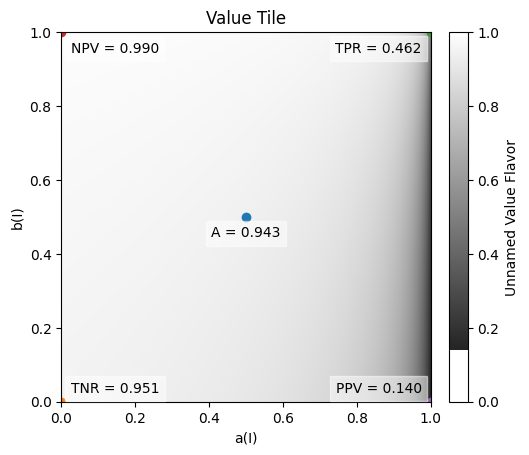

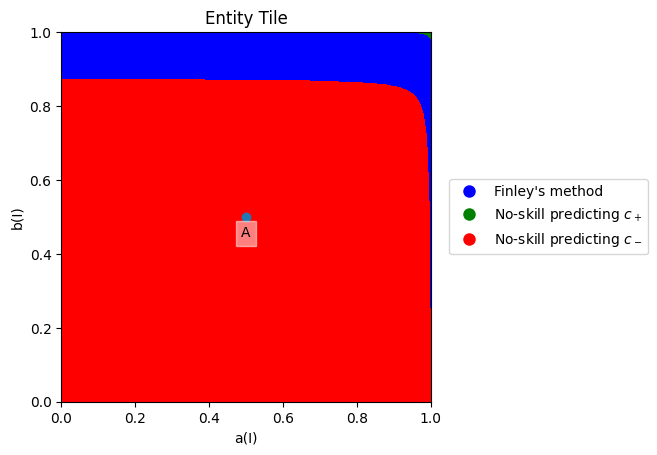

In [5]:
perf = getFinleyPerformance(43, 6, 728, 721, "March (8h)")
drawTiles(perf)

## April (8h)

The accuracy for April (8h) is 0.9817987152034261


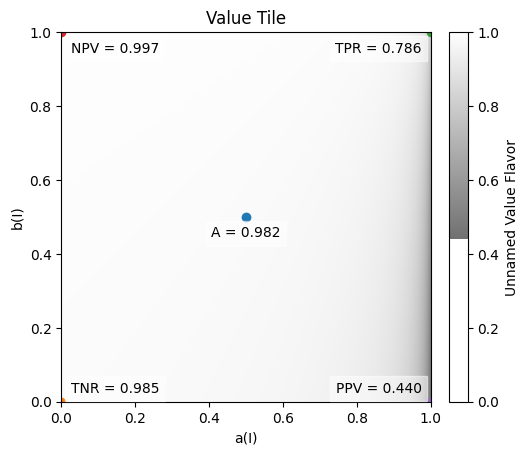

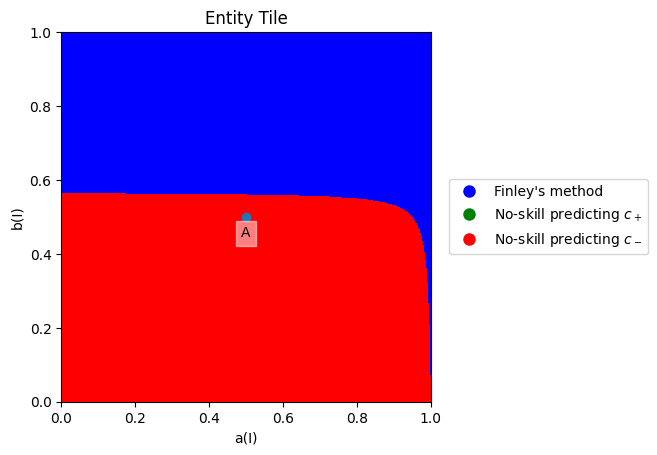

In [6]:
perf = getFinleyPerformance(25, 11, 909, 906, "April (8h)")
drawTiles(perf)

## May (8h)

The accuracy for May (8h) is 0.985663082437276


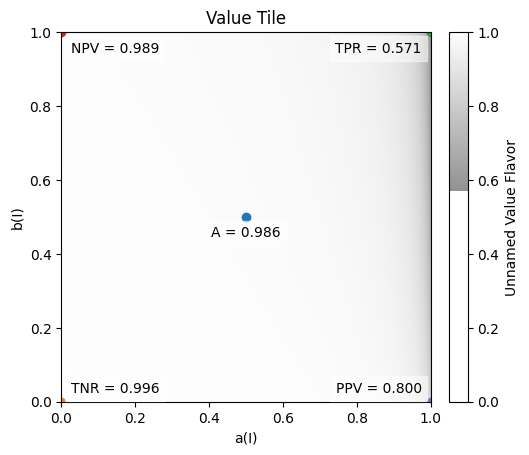

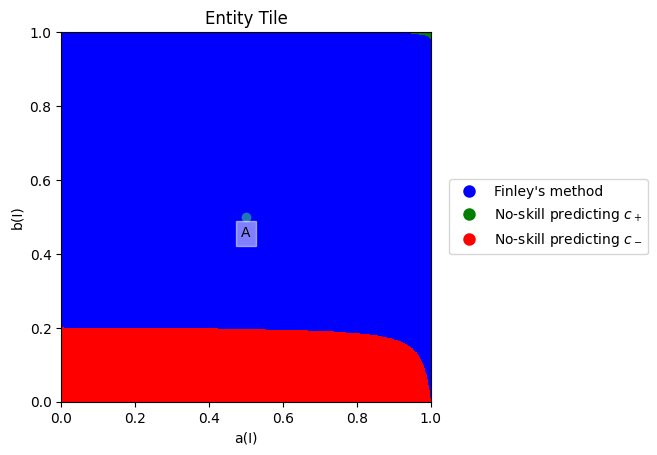

In [7]:
perf = getFinleyPerformance(10, 8, 548, 542, "May (8h)")
drawTiles(perf)

## May (16h)

The accuracy for May (16h) is 0.9518518518518518


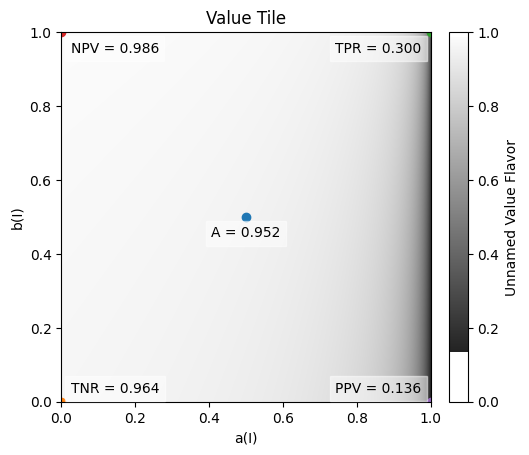

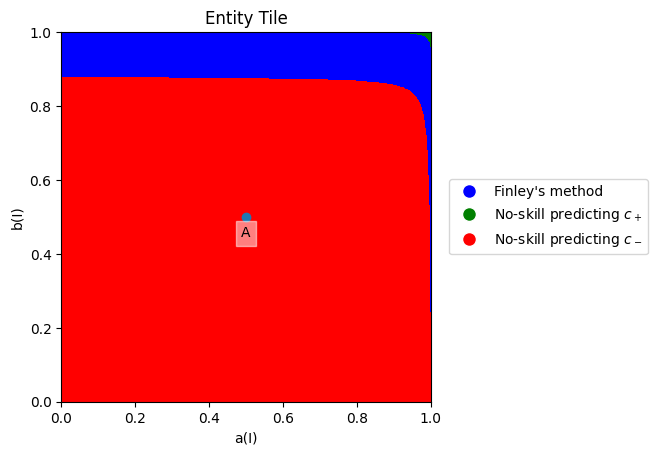

In [8]:
perf = getFinleyPerformance(22, 3, 518, 511, "May (16h)")
drawTiles(perf)

## Total

The accuracy for total is 0.9661077417053158


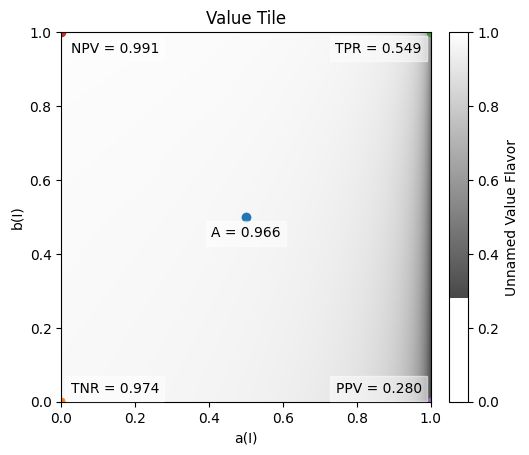

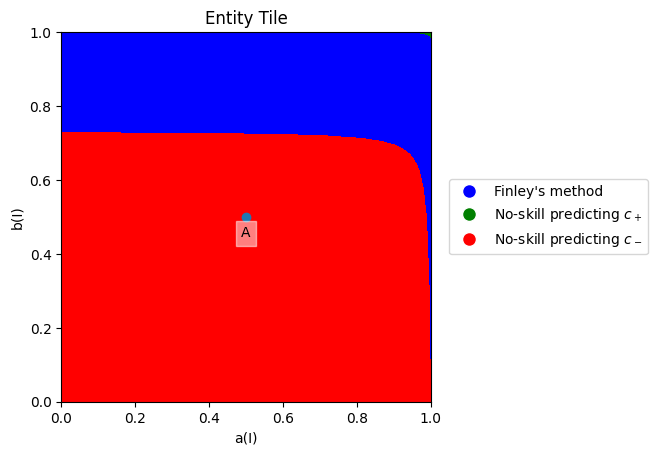

In [9]:
perf = getFinleyPerformance(
    43 + 25 + 10 + 22,
    6 + 11 + 8 + 3,
    728 + 909 + 548 + 518,
    721 + 906 + 542 + 511,
    "total",
)
drawTiles(perf)